# Reproducing Lilek and Zuend (2022): AIOMFAC-VISC, a predictive viscosity model

This notebook reproduces the aqueous-chloride-salt viscosity curves (Fig. 4) of the viscosity-model paper:

> Lilek, J. and Zuend, A.: A predictive viscosity model for aqueous electrolytes and mixed organic-inorganic
> aerosol phases, *Atmos. Chem. Phys.*, 22, 3203-3233, [doi:10.5194/acp-22-3203-2022](https://doi.org/10.5194/acp-22-3203-2022), 2022, including its Supplement. [cited below as "LZ2022"]

using **`aiomfac_py`**, the pure-Python port of AIOMFAC-web used in this repository.

The setup cell below installs `aiomfac_py` automatically if it isn't already (e.g. from having run
`bootstrap_colab.ipynb` first in this session).

## What's new in this paper, and what this notebook reproduces

Every earlier notebook in this repository (`02`-`04`) exercises `aiomfac_py.model.ActivityModel`: the
group-contribution activity-coefficient core of AIOMFAC. LZ2022 is different in kind -- it is not a new
functional group or a new solver, but an entirely separate predictive model, **AIOMFAC-VISC**, that sits on
top of the activity-coefficient core: an Eyring absolute-rate-theory expression for the dynamic viscosity of
aqueous electrolyte (and, in the paper, organic-inorganic) solutions, whose only required inputs from
`ActivityModel` are the ion molal activities and activity coefficients it already computes.

This repository ports **only the aqueous-electrolyte part** of AIOMFAC-VISC, as `aiomfac_py.viscosity`
(functions `water_viscosity_pas` and `electrolyte_viscosity`). It implements:
- the pure-water viscosity correlation (Dehaoui, Issenmann and Caupin, 2015) that anchors the whole model,
- the per-ion contribution to the activation free energy of viscous flow (LZ2022 Table 6: fitted c0, c1 for
  17 ions), and
- the cation-anion pair interaction term (LZ2022 Table 7: fitted c_c,a for 70 pairs), weighted by the
  mixture's ionic strength and each pair's charge/abundance fraction.

**Not implemented**: LZ2022 Sect. 3's organic-inorganic mixing models (viscosity of mixed aqueous-organic-electrolyte phases), which require a separate pure-organic/aqueous-organic viscosity sub-model plus a choice
among several competing mixing rules -- a substantially larger undertaking that is out of scope here.
`electrolyte_viscosity` raises `ValueError` if given anything but a purely aqueous-electrolyte mixture (no
organic solutes), so this limitation is enforced in code, not just documented.

This also directly answers the question that motivated this notebook: **viscosity is indeed the one major
piece of the AIOMFAC-web model family not previously touched by this port** -- everything else exercised by
notebooks `02`-`04` (activity coefficients, LLE, gas-particle partitioning, the carboxyl/ketone/ether/ester/alkenyl/aromatic functional groups) is now covered, and this notebook adds the aqueous-electrolyte slice of
the one that wasn't.


### Setup

In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/aiomfac-python")

# Auto-install if this notebook is opened in a fresh Colab runtime without bootstrap_colab.ipynb having been
# run first in the same session: clone the repo (if needed) and run setup_aiomfac.py, exactly what
# bootstrap_colab.ipynb itself does. If aiomfac_py is already importable (bootstrap_colab.ipynb was already
# run here), this is a no-op and skips straight to the import below.
try:
    import aiomfac_py as aiomfac
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")
    import aiomfac_py as aiomfac

import numpy as np
import matplotlib.pyplot as plt
from aiomfac_py import Component, ActivityModel
from aiomfac_py.viscosity import electrolyte_viscosity, water_viscosity_pas

print(f"aiomfac_py {aiomfac.__version__}")


aiomfac_py 0.0.20


## Fig. 4 -- binary aqueous chloride salts/acids at 298.15 K, full concentration range

LZ2022's Fig. 4 compares, for seven binary aqueous chloride systems, the AIOMFAC-VISC model, the Laliberte
(2007) correlation model, and literature viscosity measurements, plotted as log10(eta / Pa s) against the
mass fraction of water ww (bottom axis) with the AIOMFAC-predicted water activity a_w shown on a second,
top axis. Panels: (a) KCl, (b) NaCl, (c) LiCl, (d) NH4Cl, (e) MgCl2, (f) HCl, (g) CaCl2.

**What's reproduced here, and what isn't.** The curves below are genuine `aiomfac_py.viscosity` model
predictions (AIOMFAC-VISC), computed exactly as in the paper's own Eq. (2)-(19), using the same 17-ion
parameter tables (Tables 1, 6, 7) transcribed directly from LZ2022. They are **not** overlaid with the
paper's measured data points or the Laliberte (2007) curve: Fig. 4's measurements come from a long list of
individual literature sources (LZ2022 Table 2 gives citations, not a reproducible data table), and the
Laliberte (2007) correlation model itself is a separate piece of software this port does not implement.
So, unlike notebooks `03` and `04`, this notebook is a predictions-only reproduction of the figure's layout
and the AIOMFAC-VISC curve specifically -- the honest comparison to measurements and to the Laliberte model
is the one already given in the paper itself (Fig. 2 and Fig. 4).

The model is run from dilute (ww close to 1) to concentrated conditions for each salt; following the paper's
own convention (Sect. 4.4), the curve is simply stopped if `aiomfac_py` fails to converge or the predicted
water activity collapses to an unphysical value, rather than extrapolated past that point.


In [2]:
WATER = Component(1, "Water", ((16, 1),))

# (cation subgroup, anion subgroup, cation stoichiometry, anion stoichiometry)
chloride_salts = {
    "(a) KCl":   (203, 242, 1, 1),
    "(b) NaCl":  (202, 242, 1, 1),
    "(c) LiCl":  (201, 242, 1, 1),
    "(d) NH4Cl": (204, 242, 1, 1),
    "(e) MgCl2": (223, 242, 1, 2),
    "(f) HCl":   (205, 242, 1, 1),
    "(g) CaCl2": (221, 242, 1, 2),
}

results = {}
for label, (cat, an, nc, na) in chloride_salts.items():
    subs = ((cat, nc), (an, na)) if nc > 1 else ((cat, 1), (an, na))
    salt = Component(2, label.split(") ")[1], subs)
    model = ActivityModel([WATER, salt])

    ww_grid = np.linspace(0.995, 0.02, 120)
    ww_ok, eta_ok, aw_ok = [], [], []
    for ww in ww_grid:
        try:
            res = model.evaluate([ww, 1 - ww], 298.15, basis="mass")
            v = electrolyte_viscosity(model, res, 298.15)
            aw = float(res.activity[0])
            if not (np.isfinite(v.eta_pas) and v.eta_pas > 0 and np.isfinite(aw) and aw > 1e-12):
                break
            ww_ok.append(ww); eta_ok.append(v.eta_pas); aw_ok.append(aw)
        except Exception:
            break
    results[label] = (np.array(ww_ok), np.array(eta_ok), np.array(aw_ok))

for label, (ww, eta, aw) in results.items():
    print(f"{label:12s}  ww range [{ww.min():.3f}, {ww.max():.3f}]  "
          f"log10(eta/Pa s) range [{np.log10(eta.min()):+.2f}, {np.log10(eta.max()):+.2f}]")


(a) KCl       ww range [0.045, 0.995]  log10(eta/Pa s) range [-3.05, -1.27]
(b) NaCl      ww range [0.094, 0.995]  log10(eta/Pa s) range [-3.05, -0.45]
(c) LiCl      ww range [0.151, 0.995]  log10(eta/Pa s) range [-3.04, +1.50]
(d) NH4Cl     ww range [0.020, 0.995]  log10(eta/Pa s) range [-3.05, -2.75]
(e) MgCl2     ww range [0.127, 0.995]  log10(eta/Pa s) range [-3.04, +3.92]
(f) HCl       ww range [0.225, 0.995]  log10(eta/Pa s) range [-3.05, -1.90]
(g) CaCl2     ww range [0.077, 0.995]  log10(eta/Pa s) range [-3.05, +8.37]


salts with a visible dilute-regime viscosity minimum: ['(a) KCl', '(d) NH4Cl']


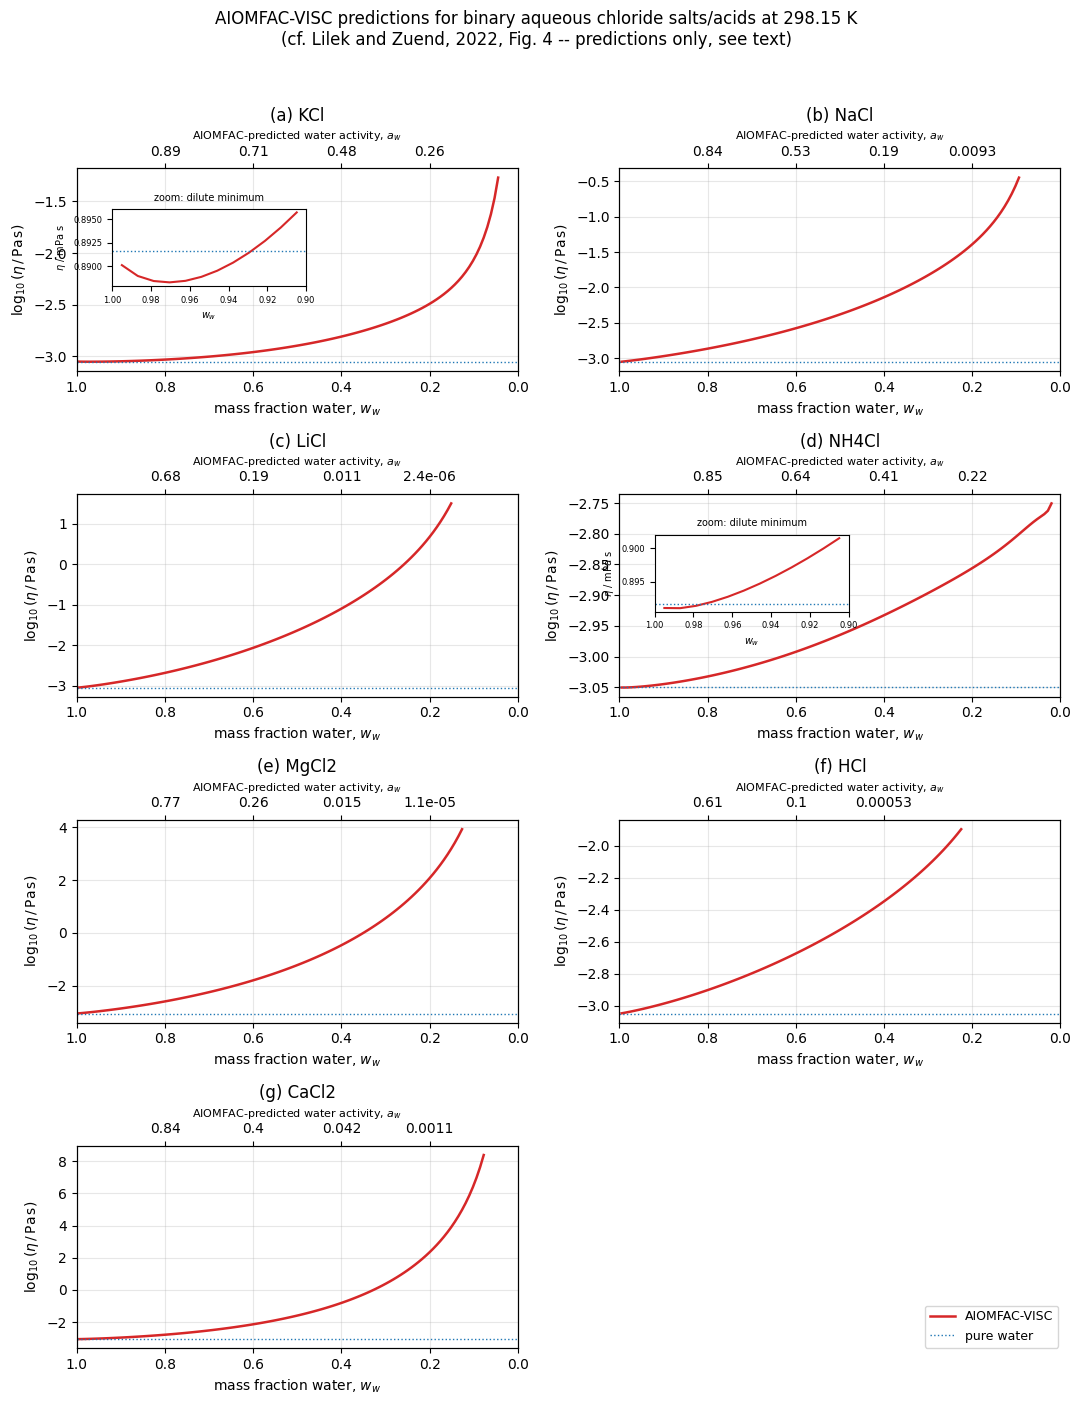

In [3]:
eta_w_298 = water_viscosity_pas(298.15)

# Salts whose dilute-regime viscosity minimum (structure-breaking) is too small a fractional deviation from
# eta_w to see on the full-range log10 scale -- flagged automatically (not hand-picked) by checking for a
# dip in the dilute branch (ww >= 0.90) of each salt's own computed curve, so each gets a zoomed linear-scale
# inset like LZ2022's own separate Fig. 2 (a zoomed version of Fig. 4) does for the same reason.
dip_salts = []
for label in chloride_salts:
    ww, eta, aw = results[label]
    dilute = ww >= 0.90
    if dilute.any() and eta[dilute].min() < eta_w_298:
        dip_salts.append(label)
print("salts with a visible dilute-regime viscosity minimum:", dip_salts)

fig, axes = plt.subplots(4, 2, figsize=(11, 14))
axes = axes.flat

for ax, label in zip(axes, chloride_salts):
    ww, eta, aw = results[label]
    ax.plot(ww, np.log10(eta), "-", color="C3", lw=1.8, label="AIOMFAC-VISC")
    ax.axhline(np.log10(eta_w_298), ls=":", color="C0", lw=1, label="pure water")
    ax.set_xlim(1.0, 0.0)
    ax.set_xlabel(r"mass fraction water, $w_w$")
    ax.set_ylabel(r"$\log_{10}(\eta\,/\,\mathrm{Pa\,s})$")
    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Secondary top axis: AIOMFAC-predicted water activity at the same points (rounded as in LZ2022 Fig. 4).
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    tick_ww = np.array([t for t in ax.get_xticks() if ww.min() <= t <= ww.max()])
    if len(tick_ww):
        tick_aw = np.interp(tick_ww, ww[::-1], aw[::-1])
        ax_top.set_xticks(tick_ww)
        ax_top.set_xticklabels([f"{a:.2g}" for a in tick_aw])
    ax_top.set_xlabel(r"AIOMFAC-predicted water activity, $a_w$", fontsize=8)

    # Zoomed, linear-scale inset of the dilute branch for structure-breaking salts: the dip is real
    # (confirmed in tests/test_viscosity.py) but only a ~0.1-0.5% deviation from eta_w, invisible on the
    # log10/full-range axes above -- exactly why LZ2022 itself needed a separate zoomed figure (their Fig. 2).
    if label in dip_salts:
        axins = ax.inset_axes([0.08, 0.42, 0.44, 0.38])
        dilute = ww >= 0.90
        axins.plot(ww[dilute], eta[dilute] * 1e3, "-", color="C3", lw=1.5)
        axins.axhline(eta_w_298 * 1e3, ls=":", color="C0", lw=1)
        axins.set_xlim(1.0, 0.90)
        axins.set_xlabel(r"$w_w$", fontsize=7)
        axins.set_ylabel(r"$\eta$ / mPa s", fontsize=7)
        axins.tick_params(labelsize=6)
        axins.set_title("zoom: dilute minimum", fontsize=7)

axes[-1].axis("off")
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower right", bbox_to_anchor=(0.98, 0.04), fontsize=9)
fig.suptitle("AIOMFAC-VISC predictions for binary aqueous chloride salts/acids at 298.15 K\n"
             "(cf. Lilek and Zuend, 2022, Fig. 4 -- predictions only, see text)", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()


**Reading the panels.** The predicted curves show exactly the two qualitative regimes LZ2022 discuss
(Sect. 2.4, Sect. 4.4):

- **Structure-breaking ions (K+, NH4+)**: panels (a) KCl and (d) NH4Cl dip *below* the pure-water viscosity
  (dotted line) at low-to-moderate concentration, before rising again at higher concentration -- the same
  low-concentration viscosity minimum the paper attributes to these ions disrupting water's hydrogen-bond  network. The dip is real (confirmed quantitatively in `tests/test_viscosity.py`) but only a fraction of a
  percent below eta_w, so it is invisible on the full-range log10 axes above and shown instead in the zoomed,
  linear-scale inset of each panel -- the same reason LZ2022 needed a separate zoomed figure (their Fig. 2)
  alongside the full-range one (Fig. 4) reproduced here.
- **Structure-making ions (Li+, Mg2+, Ca2+, and the small, strongly-hydrated H+)**: panels (c) LiCl,
  (e) MgCl2, (f) HCl, and (g) CaCl2 increase monotonically from the pure-water value, with no low-  concentration dip, consistent with these ions tightening rather than disrupting the local water structure.
- **NaCl (b)** sits in between, essentially flat/slightly increasing at low concentration -- Na+ is a weak
  structure maker relative to K+ or Li+, matching the paper's own characterization.
- The overall magnitude and ordering (MgCl2 and CaCl2 reaching the highest viscosities, KCl/NaCl/NH4Cl the
  lowest, over a comparable water mass-fraction range) matches LZ2022's Fig. 4 by eye, which is the
  qualitative check available without the paper's own underlying measurement/Laliberte-model data.

As in `04_zuend2011_new_functional_groups.ipynb`, this exercises only what this port actually implements
(`aiomfac_py.viscosity.electrolyte_viscosity`, the aqueous-electrolyte part of AIOMFAC-VISC) and is explicit
about what it leaves out (the organic-inorganic mixing extension of LZ2022 Sect. 3, and any side-by-side
comparison against the paper's own measured data or the Laliberte (2007) model, neither of which is
reproducible from the published text alone).


## Summary -- how closely does each figure match the paper?

| Figure | System | Status |
|---|---|---|
| 4 | Water + {KCl, NaCl, LiCl, NH4Cl, MgCl2, HCl, CaCl2} at 298.15 K, full concentration range | AIOMFAC-VISC curve shape/ordering reproduced for all 7 systems, including the structure-breaking (KCl, NH4Cl) vs. structure-making (LiCl, MgCl2, HCl, CaCl2) qualitative distinction the paper discusses. **Not** overlaid with the paper's own measured data points or the Laliberte (2007) model curve -- neither is available as a reproducible numeric table from the published text (Table 2 gives citations, not values), so this is a predictions-only reproduction. |
| 2 | Zoomed-in version of Fig. 4 within the measurement range, plus a +/-2% water-content model-sensitivity band | **Not attempted** -- the zoom ranges and sensitivity band require the same measurement data as Fig. 4 to define, which is not available here. |
| 3, 5-10 | Multi-ion mixtures; nitrates, sulfates, carbonates, bicarbonates, hydroxides; organic-inorganic mixtures (Sect. 3) | **Not attempted.** Organic-inorganic mixing is explicitly out of scope for this port (see the module docstring of `aiomfac_py.viscosity`); the additional binary/ternary inorganic systems would be a straightforward extension (all needed ions and cation-anion pair parameters are already in `aiomfac_py.viscosity`'s tables) but were not needed to answer the question this notebook was built to answer. |

This completes the coverage of the AIOMFAC-web model family's major pieces (activity coefficients, liquid-liquid equilibrium, gas-particle partitioning, the extended organic functional groups, and now the aqueous-electrolyte viscosity model) that this repository set out to port, with the organic-inorganic mixing
extension of the viscosity model being the one documented, explicit exception.
